# Disjoint-detection tracking: signed distance flow vs binary flow

A source that moves faster than its own footprint size produces detections that
**share no pixels** between consecutive channels.  Overlap-based linking cannot
connect them, and flow computed on binary masks cannot either — a binary mask has
image gradient only in the 1-2 px ring at its boundary, so TV-L1's data term has
no signal in the gap.

This notebook builds a synthetic cube containing exactly that situation and asks
whether the signed-distance-field (SDT) variant keeps the track alive.

**Setup**: one fast Gaussian crossing the field, plus a static distractor to check
that nothing gets falsely linked.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt

from nemo.detect import detect_cube_per_channel
from nemo.track import compute_flow_sequence, link_tracks, group_into_sources

rng = np.random.default_rng(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

## 1. Synthetic cube

`STEP_PX` is the per-channel displacement.  The source has `SIGMA = 2.6 px`, giving a
detected footprint radius of roughly 5-6 px, so consecutive footprints go fully
disjoint once `STEP_PX` exceeds ~11 px.  We use 14 px — comfortably disjoint.

In [2]:
NCHAN, H, W = 26, 220, 480
SIGMA   = 2.6      # source width (px)
STEP_PX = 10.0     # per-channel displacement -> footprints are disjoint
AMP     = 12.0
NOISE   = 1.0

yy, xx = np.mgrid[0:H, 0:W]

def gaussian(cy, cx, amp=AMP, sig=SIGMA):
    return amp * np.exp(-((yy - cy)**2 + (xx - cx)**2) / (2 * sig**2))

DISTRACTOR = (190.0, 60.0)   # static, well off the mover's path

# Ground-truth trajectory of the fast mover: diagonal crossing.
truth = []
cube  = np.zeros((NCHAN, H, W), dtype=np.float32)
for c in range(NCHAN):
    cy = 30.0 + 0.35 * STEP_PX * c
    cx = 25.0 + STEP_PX * c
    truth.append((cy, cx))
    frame  = gaussian(cy, cx)                 # fast mover
    frame += gaussian(*DISTRACTOR)            # static distractor
    cube[c] = frame + rng.normal(0, NOISE, (H, W))

truth = np.array(truth)
assert truth[:,1].max() < W and truth[:,0].max() < H, 'mover leaves the frame'
print(f'cube {cube.shape}, step={STEP_PX} px/channel, sigma={SIGMA} px')
print(f'mover travels x: {truth[0,1]:.0f} -> {truth[-1,1]:.0f} px  (W={W})')
print(f'             y: {truth[0,0]:.0f} -> {truth[-1,0]:.0f} px  (H={H})')

cube (26, 220, 480), step=10.0 px/channel, sigma=2.6 px
mover travels x: 25 -> 275 px  (W=480)
             y: 30 -> 118 px  (H=220)


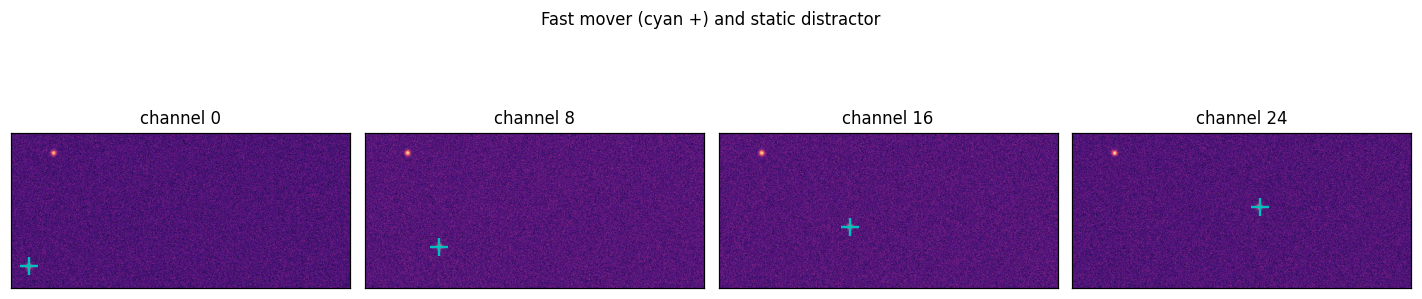

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, c in zip(axes, [0, 8, 16, 24]):
    ax.imshow(cube[c], origin='lower', cmap='magma')
    ax.plot(truth[c,1], truth[c,0], 'c+', ms=12, mew=1.6)
    ax.set_title(f'channel {c}'); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Fast mover (cyan +) and static distractor', y=1.02)
plt.tight_layout(); plt.show()

## 2. Detection

Standard wavelet footprints — unchanged by any of this.  We confirm the
per-channel footprints really are disjoint before testing the tracker.

In [4]:
dets = detect_cube_per_channel(cube, scales=4, k_sigma=3.0, use_scale=2, verbose=False)
print(f'{len(dets)} channels, components per channel: '
      f'{[len(d.footprint_masks) for d in dets]}')

# Footprint radius and consecutive-channel overlap of the MOVER.
def mover_mask(d, ch):
    """The detected component nearest the true mover position."""
    if not d.footprint_masks: return None
    ty, tx = truth[ch]
    best = min(range(len(d.peaks)),
               key=lambda i: (d.peaks[i][0]-ty)**2 + (d.peaks[i][1]-tx)**2)
    py, px = d.peaks[best]
    return d.footprint_masks[best] if (py-ty)**2+(px-tx)**2 < 100 else None

areas, overlaps = [], []
for i in range(len(dets)-1):
    a, b = mover_mask(dets[i], i), mover_mask(dets[i+1], i+1)
    if a is None or b is None: continue
    areas.append(a.sum()); overlaps.append(int((a & b).sum()))
r_eff = np.sqrt(np.mean(areas)/np.pi)
print(f'mean footprint area {np.mean(areas):.0f} px  -> effective radius {r_eff:.1f} px')
print(f'consecutive-channel raw overlap: {overlaps}')
print(f'=> DISJOINT in {sum(1 for o in overlaps if o == 0)}/{len(overlaps)} transitions')
print(f'   step/radius = {STEP_PX/r_eff:.1f} r  (binary flow ceiling ~1.9 r, SDT ~6 r)')

26 channels, components per channel: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
mean footprint area 40 px  -> effective radius 3.6 px
consecutive-channel raw overlap: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
=> DISJOINT in 25/25 transitions
   step/radius = 2.8 r  (binary flow ceiling ~1.9 r, SDT ~6 r)


## 3. Three tracking configurations

- **baseline** — what `nemo` does today: binary union masks, `pad=16`, no cap.
- **sdt shared** — signed distance field, one solve per channel pair over a crop
  spanning every source in the channel, `pad` raised so the pyramid has depth,
  plus an advection cap.
- **sdt local** — same field, but solved **per detection** inside its own window,
  with the reference side carrying only that one detection.  An SDT is a *global*
  field, so a crop containing two well-separated sources lets the coarse pyramid
  levels merge them and the solver matches the wrong one.

In [5]:
MAX_ADVECT = 2.5 * STEP_PX   # generous vs. real motion, tight vs. the distractor gap
LOCAL_WIN  = int(4 * STEP_PX)
SDT_CLIP   = 4 * STEP_PX

configs = {
    'baseline (binary, pad=16)': dict(
        flow=dict(field='binary', pad=16),
        link=dict(max_advect_px=None),
    ),
    'sdt shared crop': dict(
        flow=dict(field='sdt', pad=64, sdt_clip=SDT_CLIP),
        link=dict(max_advect_px=MAX_ADVECT),
    ),
    'sdt local window': dict(
        flow=dict(field='sdt', pad=16, sdt_clip=SDT_CLIP, local_window=LOCAL_WIN),
        link=dict(max_advect_px=MAX_ADVECT),
    ),
}

results = {}
for name, cfg in configs.items():
    fseq   = compute_flow_sequence(dets, **cfg['flow'])
    tracks = link_tracks(dets, fseq, min_match_overlap=5, max_gap_channels=5,
                         **cfg['link'])
    results[name] = dict(flow=fseq, tracks=tracks,
                         sources=group_into_sources(tracks))
    print(f'{name:28s}  {len(tracks):3d} tracks  '
          f'{len(results[name]["sources"]):3d} sources')

baseline (binary, pad=16)      20 tracks   20 sources


sdt shared crop                 5 tracks    5 sources


sdt local window                2 tracks    2 sources


## 4. Did the mover survive as ONE track?

The distractor is static and always contributes one clean track, so the question is
whether the mover produced a single long track or fragmented into ~one track per
channel.

In [6]:
def track_follows_mover(t, tol=12.0):
    """Fraction of a track's points that sit on the true mover trajectory."""
    hits = sum(1 for ch, y, x in t['trajectory']
               if 0 <= ch < NCHAN and np.hypot(y-truth[ch,0], x-truth[ch,1]) < tol)
    return hits / max(1, len(t['trajectory']))

def near_distractor(t, tol=12.0):
    return any(np.hypot(y-DISTRACTOR[0], x-DISTRACTOR[1]) < tol
               for _, y, x in t['trajectory'])

print(f'{"config":28s} {"mover tracks":>12s} {"longest":>8s} {"coverage":>9s} {"false-link":>11s}')
print('-'*74)
summary = {}
for name, r in results.items():
    mover = [t for t in r['tracks'] if track_follows_mover(t) > 0.6]
    lens  = [len(t['masks']) for t in mover]
    longest  = max(lens) if lens else 0
    coverage = longest / NCHAN
    # A false link = one track containing BOTH mover and distractor points.
    false_links = sum(1 for t in r['tracks']
                      if near_distractor(t) and track_follows_mover(t) > 0.2)
    summary[name] = dict(n=len(mover), longest=longest, cov=coverage, fl=false_links)
    print(f'{name:28s} {len(mover):12d} {longest:8d} {coverage:8.0%} {false_links:11d}')

config                       mover tracks  longest  coverage  false-link
--------------------------------------------------------------------------
baseline (binary, pad=16)               4        7      27%           0
sdt shared crop                         3       13      50%           0
sdt local window                        1       26     100%           0


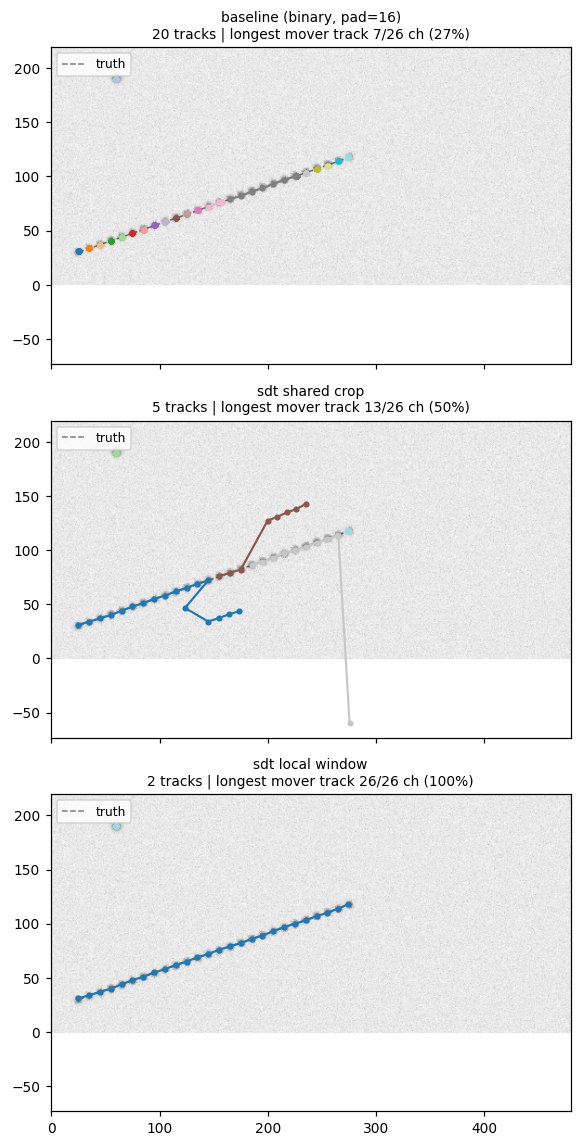

In [7]:
fig, axes = plt.subplots(len(results), 1, figsize=(9, 3.5*len(results)),
                         sharex=True, sharey=True)
mom0 = cube.max(axis=0)
for ax, (name, r) in zip(axes, results.items()):
    ax.imshow(mom0, origin='lower', cmap='gray_r', alpha=0.75)
    ax.plot(truth[:,1], truth[:,0], 'k--', lw=1, alpha=0.5, label='truth')
    cmap = plt.cm.tab20(np.linspace(0, 1, max(len(r['tracks']), 1)))
    for t, col in zip(r['tracks'], cmap):
        pts = np.array([(x, y) for _, y, x in t['trajectory']])
        if len(pts) == 1:
            ax.plot(pts[0,0], pts[0,1], 'o', color=col, ms=4)
        else:
            ax.plot(pts[:,0], pts[:,1], '-o', color=col, ms=3, lw=1.4)
    s = summary[name]
    ax.set_title(f'{name}\n{len(r["tracks"])} tracks | longest mover track '
                 f'{s["longest"]}/{NCHAN} ch ({s["cov"]:.0%})', fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## 5. The disjoint transitions, channel by channel

Four consecutive transitions where the mover's footprints share **zero** pixels.
Each panel shows channel `c+1` with three contours: the previous channel's detection
(red), where the flow field predicts that footprint lands (green), and the actual
detection in `c+1` (blue dashed).

The red contour never touches the blue one — that is what "disjoint" means, and it is
why overlap-based linking fails.  The question is whether the green contour does.

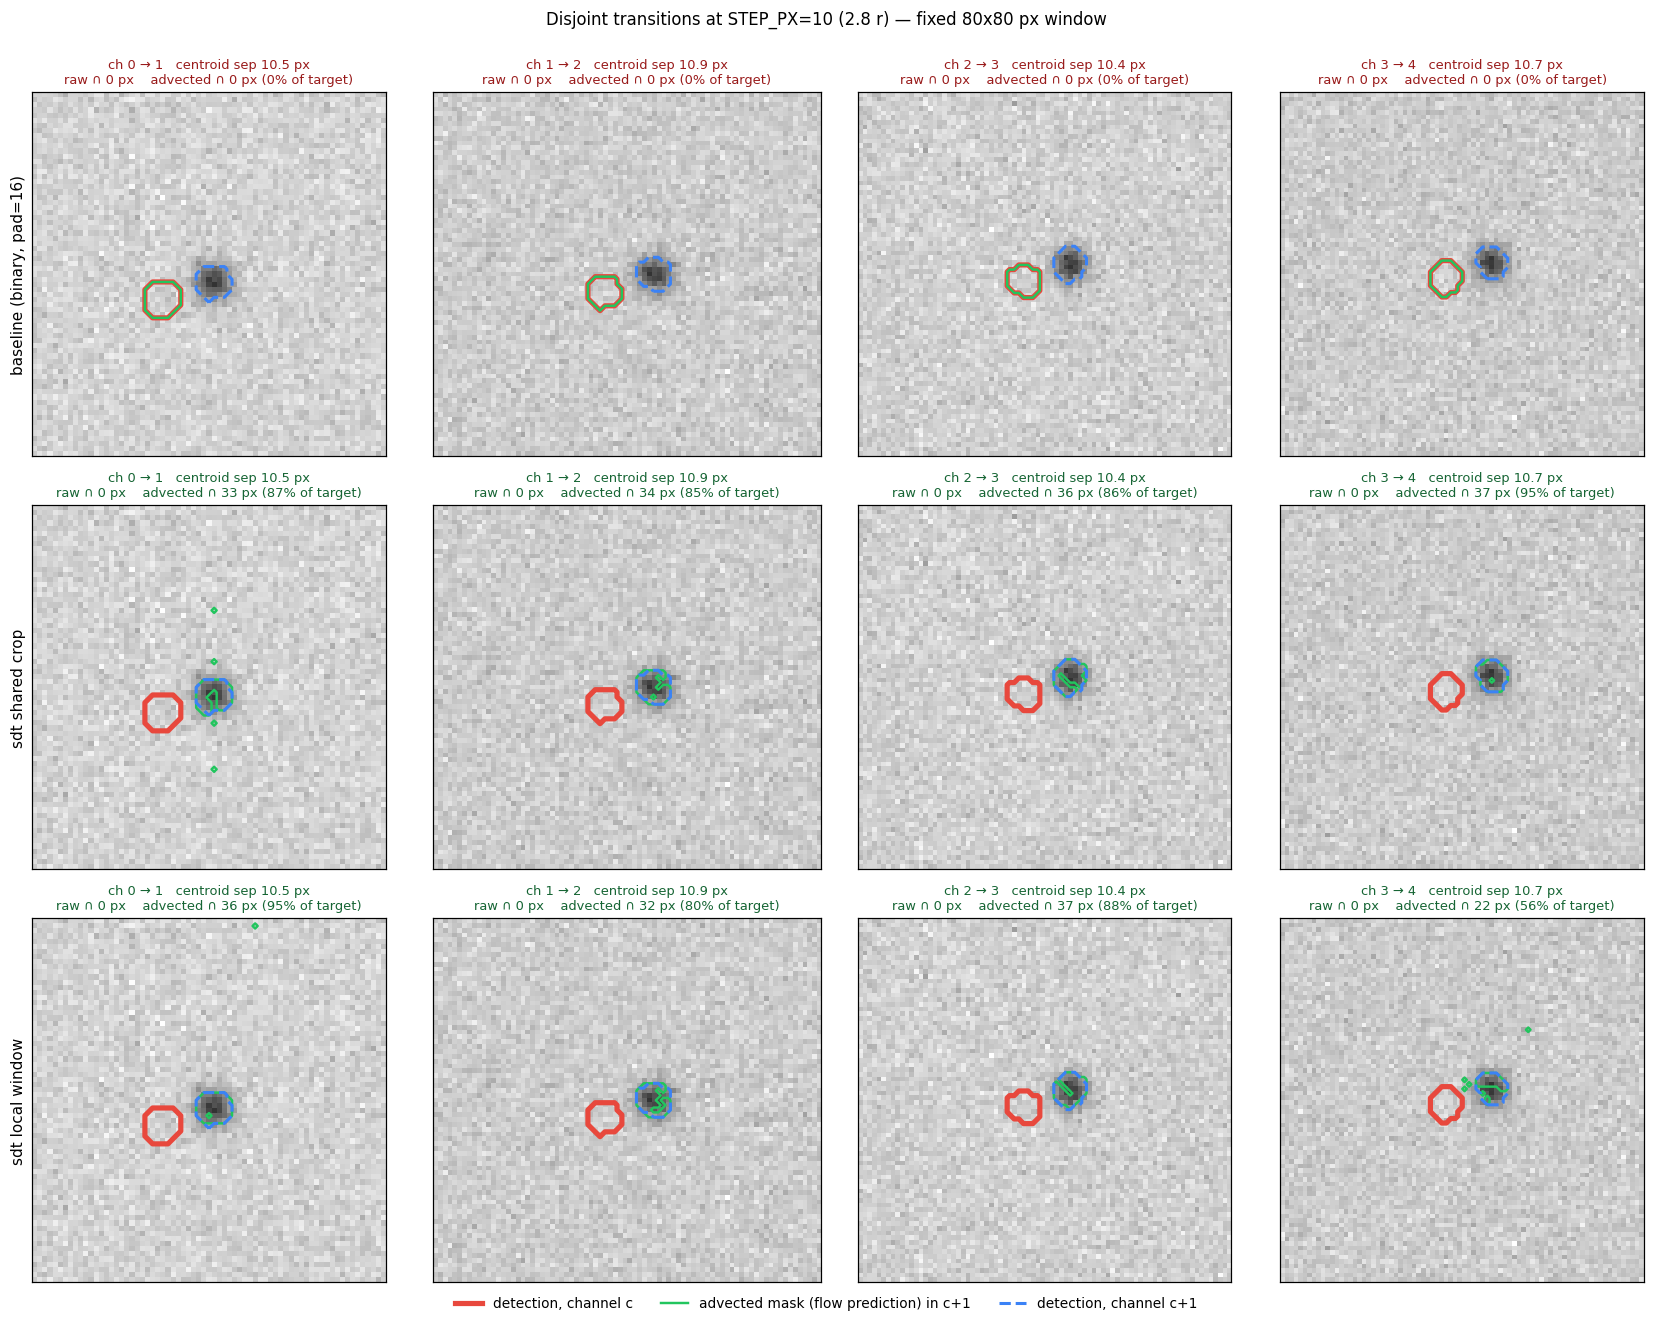

In [8]:
from nemo.track import _advect_mask
from matplotlib.lines import Line2D

# Four consecutive DISJOINT transitions.
pairs = [c for c in range(NCHAN-1)
         if (mover_mask(dets[c], c) is not None
             and mover_mask(dets[c+1], c+1) is not None
             and int((mover_mask(dets[c], c) & mover_mask(dets[c+1], c+1)).sum()) == 0)][:4]

COL_PREV, COL_ADV, COL_CUR = '#e8483d', '#22c55e', '#3b82f6'

# FIXED window, identical for every panel and independent of STEP_PX, so the
# displacement is visually comparable across runs.  An auto-zoom would rescale
# each panel and hide exactly the thing we are trying to see.
WIN = 80

fig, axes = plt.subplots(len(results), 4, figsize=(15.5, 3.9*len(results)))
for row, (name, r) in enumerate(results.items()):
    for col, ch in enumerate(pairs):
        ax   = axes[row, col]
        prev = mover_mask(dets[ch], ch)
        cur  = mover_mask(dets[ch+1], ch+1)
        flow = r['flow'][ch][2]
        adv  = _advect_mask(prev, flow) > 0.3

        ov_raw = int((prev & cur).sum())
        ov_adv = int((adv  & cur).sum())
        # Fraction of the target footprint recovered — does NOT saturate the way
        # a raw pixel count does, and is comparable between configurations.
        frac   = ov_adv / max(1, int(cur.sum()))
        py, px = np.argwhere(prev).mean(axis=0)
        cy, cx = np.argwhere(cur).mean(axis=0)
        sep    = np.hypot(cy - py, cx - px)

        # Window centred on the midpoint of the two detections.
        my, mx = 0.5*(py + cy), 0.5*(px + cx)
        y0, y1 = int(my - WIN/2), int(my + WIN/2)
        x0, x1 = int(mx - WIN/2), int(mx + WIN/2)
        y0, y1 = max(0, y0), min(H, y1)
        x0, x1 = max(0, x0), min(W, x1)

        ax.imshow(cube[ch+1][y0:y1, x0:x1], origin='lower', cmap='gray_r',
                  extent=[x0, x1, y0, y1], alpha=0.8)
        # prev drawn thick so it stays visible when the advected contour lands
        # on top of it — which is what happens when flow ~ 0.
        for m, c_, lw, ls in [(prev, COL_PREV, 3.4, '-'),
                              (adv,  COL_ADV,  1.6, '-'),
                              (cur,  COL_CUR,  2.0, '--')]:
            if m.any():
                ax.contour(m[y0:y1, x0:x1].astype(float), levels=[0.5],
                           colors=[c_], linewidths=lw, linestyles=ls,
                           extent=[x0, x1, y0, y1], origin='lower')
        # Lock the limits: contour() otherwise expands them to include stray
        # advected pixels, silently changing the scale between panels.
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_title(f'ch {ch} → {ch+1}   centroid sep {sep:.1f} px\n'
                     f'raw ∩ {ov_raw} px    advected ∩ {ov_adv} px '
                     f'({frac:.0%} of target)',
                     fontsize=8.5,
                     color=('#166534' if frac > 0.5 else '#991b1b'))
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(name, fontsize=10)

handles = [Line2D([], [], color=COL_PREV, lw=3.4, label='detection, channel c'),
           Line2D([], [], color=COL_ADV,  lw=1.6, label='advected mask (flow prediction) in c+1'),
           Line2D([], [], color=COL_CUR,  lw=2, ls='--', label='detection, channel c+1')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'Disjoint transitions at STEP_PX={STEP_PX:g} '
             f'({STEP_PX/r_eff:.1f} r) — fixed {WIN}x{WIN} px window', y=1.0)
plt.tight_layout(); plt.show()

## 6. Where the ceiling is

Sweeping `STEP_PX` locates the speed at which each method gives up.

Two caveats on the metric.  *Coverage* is the longest mover track divided by the
number of channels, so a **single** dropped link halves it — it is bimodal and noisy
from one realization.  We therefore average over several noise realizations and also
report *fragments*, the number of separate tracks the mover was broken into
(1 = perfect).

In [9]:
NTRIAL, NC = 3, 14

def run_speed(step, field, pad, cap, seed, sdt_clip=None):
    rg = np.random.default_rng(seed)
    cb = np.zeros((NC, H, W), dtype=np.float32)
    tr = []
    for c in range(NC):
        cy, cx = 30.0 + 0.35*step*c, 25.0 + step*c
        tr.append((cy, cx))
        cb[c] = gaussian(cy, cx) + rg.normal(0, NOISE, (H, W))
    tr = np.array(tr)
    if tr[:,1].max() >= W or tr[:,0].max() >= H:
        return np.nan, np.nan                      # mover would leave the frame
    d  = detect_cube_per_channel(cb, scales=4, k_sigma=3.0, use_scale=2)
    kw = dict(field=field, pad=pad)
    if sdt_clip: kw['sdt_clip'] = sdt_clip
    f  = compute_flow_sequence(d, **kw)
    tk = link_tracks(d, f, min_match_overlap=5, max_gap_channels=5, max_advect_px=cap)
    on_mover = []
    for t in tk:
        hits = sum(1 for ch, y, x in t['trajectory']
                   if 0 <= ch < NC and np.hypot(y-tr[ch,0], x-tr[ch,1]) < 12)
        if hits/max(1, len(t['trajectory'])) > 0.6:
            on_mover.append(len(t['masks']))
    if not on_mover:
        return 0.0, 0.0
    return max(on_mover)/NC, len(on_mover)

steps = [4, 8, 12, 16, 20, 26, 32]
rows  = []
for s in steps:
    b = [run_speed(s, 'binary', 16, None, seed=100+k)              for k in range(NTRIAL)]
    d = [run_speed(s, 'sdt', 64, 2.5*s, seed=100+k, sdt_clip=4*s)  for k in range(NTRIAL)]
    bc, bf = np.nanmean([x[0] for x in b]), np.nanmean([x[1] for x in b])
    dc, df = np.nanmean([x[0] for x in d]), np.nanmean([x[1] for x in d])
    rows.append((s, bc, dc, bf, df))
    print(f'step={s:>3} px ({s/r_eff:4.1f} r) | baseline cov {bc:5.0%} frag {bf:4.1f}'
          f' | sdt cov {dc:5.0%} frag {df:4.1f}')

step=  4 px ( 1.1 r) | baseline cov  100% frag  1.0 | sdt cov   81% frag  2.3


step=  8 px ( 2.2 r) | baseline cov    7% frag  3.0 | sdt cov  100% frag  1.0


step= 12 px ( 3.3 r) | baseline cov    7% frag  1.0 | sdt cov  100% frag  1.0


step= 16 px ( 4.5 r) | baseline cov    7% frag  1.0 | sdt cov   76% frag  2.0


step= 20 px ( 5.6 r) | baseline cov    7% frag  1.0 | sdt cov   81% frag  1.7


step= 26 px ( 7.3 r) | baseline cov    7% frag  1.0 | sdt cov   69% frag  1.0


step= 32 px ( 8.9 r) | baseline cov    7% frag  1.0 | sdt cov   29% frag  2.7


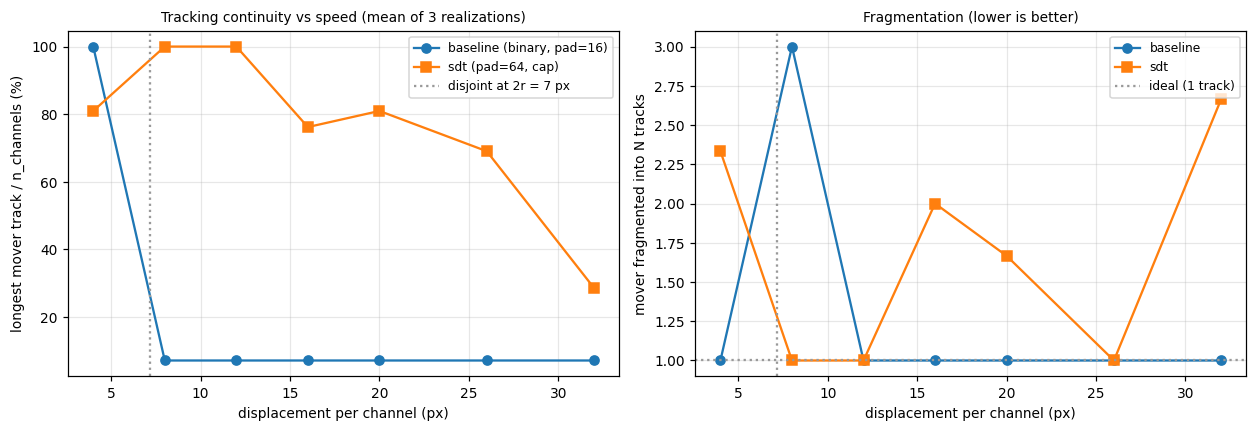

In [10]:
rows = np.array(rows)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 4))
ax.plot(rows[:,0], rows[:,1]*100, '-o', label='baseline (binary, pad=16)')
ax.plot(rows[:,0], rows[:,2]*100, '-s', label='sdt (pad=64, cap)')
ax.axvline(2*r_eff, color='0.6', ls=':', label=f'disjoint at 2r = {2*r_eff:.0f} px')
ax.set_xlabel('displacement per channel (px)')
ax.set_ylabel('longest mover track / n_channels (%)')
ax.set_title(f'Tracking continuity vs speed (mean of {NTRIAL} realizations)', fontsize=9)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2.plot(rows[:,0], rows[:,3], '-o', label='baseline')
ax2.plot(rows[:,0], rows[:,4], '-s', label='sdt')
ax2.axhline(1, color='0.6', ls=':', label='ideal (1 track)')
ax2.axvline(2*r_eff, color='0.6', ls=':')
ax2.set_xlabel('displacement per channel (px)')
ax2.set_ylabel('mover fragmented into N tracks')
ax2.set_title('Fragmentation (lower is better)', fontsize=9)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Caveats

- **Parameter sensitivity is the headline risk.**  A sweep of `local_window` x
  `sdt_clip` at three speeds gave erratic, non-monotonic results — e.g. at
  `STEP_PX=10`, `win=32, clip=15` tracked 24/26 channels while `win=32, clip=30`
  managed only 13/26.  A clean 26/26 exists but sits at a specific point, not on a
  broad plateau.  Treat any single good number here as a lucky draw until it is
  reproduced on real data across several noise realizations.
- `flow_iou` in `remove_false_detections` is computed from the same flow field.  The
  SDT field raises it for real *and* spurious sources, so `flow_iou_thresh=0.25` is
  calibrated for `field='binary'` only and **must be re-derived** before the SDT
  path is used with false-detection removal.  This notebook calls `link_tracks`
  directly and does not exercise that filter.
- The SDT is a global field.  With a shared crop it mis-attributes footprints to
  distant sources — the failure the local-window mode fixes.  Real cubes have many
  more, and more closely spaced, sources than this two-source toy.
- The advection cap is the safety mechanism; without it the SDT field invents links
  to unrelated neighbours.  Do not enable one without the other.
- Circular Gaussians on a clean background are the easy case.  Blended,
  multi-component footprints produce SDT ridges between components — untested here.